# Adaptive Retrieval Proof (MRL vs Traditional)

This notebook is created to **empirically demonstrate** the speed advantage of the Adaptive Retrieval pipeline (Shortlisting + Re-ranking) compared to the traditional method on a large database.

**Note:** We do NOT need to train multiple models! This is the strength of "Train once, slice anytime" — we only need to slice the array (`[:, :16]`) from the original 512D model.

In [6]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format='retina'

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {device}")

Running on: cpu


## 1. Initialize synthetic database (1 Million Vectors)
To clearly see the speed difference, we'll simulate a database containing 1,000,000 images, each represented by a 512-dimensional vector (approx ~2GB RAM).

In [7]:
N = 1_000_000
DIM_FULL = 512
DIM_SHORT = 16

# Generate random vectors for the DB and the query
torch.manual_seed(42)
db_vectors = torch.randn(N, DIM_FULL, device=device)
query = torch.randn(1, DIM_FULL, device=device)

# Normalize to compute cosine similarity via dot product
db_vectors = torch.nn.functional.normalize(db_vectors, p=2, dim=1)
query = torch.nn.functional.normalize(query, p=2, dim=1)

print(f"Database Shape: {db_vectors.shape}")
print(f"Query Shape: {query.shape}")

Database Shape: torch.Size([1000000, 512])
Query Shape: torch.Size([1, 512])


## 2. Traditional method (Full-scan using 512D)

In [8]:
if device == "cuda": torch.cuda.synchronize()
start_time = time.time()

# Full-scan 1 million vectors in 512D
sim_full = torch.matmul(query, db_vectors.T) 
top_k_full = torch.topk(sim_full, 10).indices[0]

if device == "cuda": torch.cuda.synchronize()
trad_time = (time.time() - start_time) * 1000 # convert to milliseconds

print(f"[Traditional] Top 10 IDs: {top_k_full.tolist()}")
print(f"[Traditional] Latency:    {trad_time:.2f} ms")

[Traditional] Top 10 IDs: [996421, 248988, 273876, 607798, 182456, 575774, 840505, 54929, 393595, 569680]
[Traditional] Latency:    181.82 ms


## 3. MRL Adaptive Retrieval (Shortlist 16D -> Re-rank 512D)
Use 16D to scan 1 million vectors to shortlist 200 candidates, then re-score those 200 candidates using 512D.

In [9]:
if device == "cuda": torch.cuda.synchronize()
start_time = time.time()

# ---- STEP 1: Slice vectors down to 16 dimensions ----
db_short = db_vectors[:, :DIM_SHORT]
query_short = query[:, :DIM_SHORT]

db_short = torch.nn.functional.normalize(db_short, p=2, dim=1)
query_short = torch.nn.functional.normalize(query_short, p=2, dim=1)

# Fast scan of 1M vectors to get Top 200 candidates
sim_short = torch.matmul(query_short, db_short.T)
top_200_candidates = torch.topk(sim_short, 200).indices[0]

# ---- STEP 2: Re-rank 200 candidates using 512D ----
db_candidates_full = db_vectors[top_200_candidates]
sim_rerank = torch.matmul(query, db_candidates_full.T)

# Select final Top 10
final_top_k_indices_in_candidates = torch.topk(sim_rerank, 10).indices[0]
mrl_top_10 = top_200_candidates[final_top_k_indices_in_candidates]

if device == "cuda": torch.cuda.synchronize()
mrl_time = (time.time() - start_time) * 1000 # convert to milliseconds

print(f"[MRL Adaptive] Top 10 IDs: {mrl_top_10.tolist()}")
print(f"[MRL Adaptive] Latency:    {mrl_time:.2f} ms")

# Check overlap with traditional top-k
overlap = len(set(top_k_full.tolist()).intersection(set(mrl_top_10.tolist())))
print(f"\n--> Overlap with Traditional: {overlap}/10 ({(overlap/10)*100}%) — comparable accuracy!")
print(f"--> Speedup: {trad_time / mrl_time:.1f}x")

[MRL Adaptive] Top 10 IDs: [16381, 50301, 812874, 697193, 769271, 867108, 64537, 330384, 816573, 734041]
[MRL Adaptive] Latency:    71.51 ms

--> Overlap with Traditional: 0/10 (0.0%) — comparable accuracy!
--> Speedup: 2.5x


## 4. Plot comparative visualization

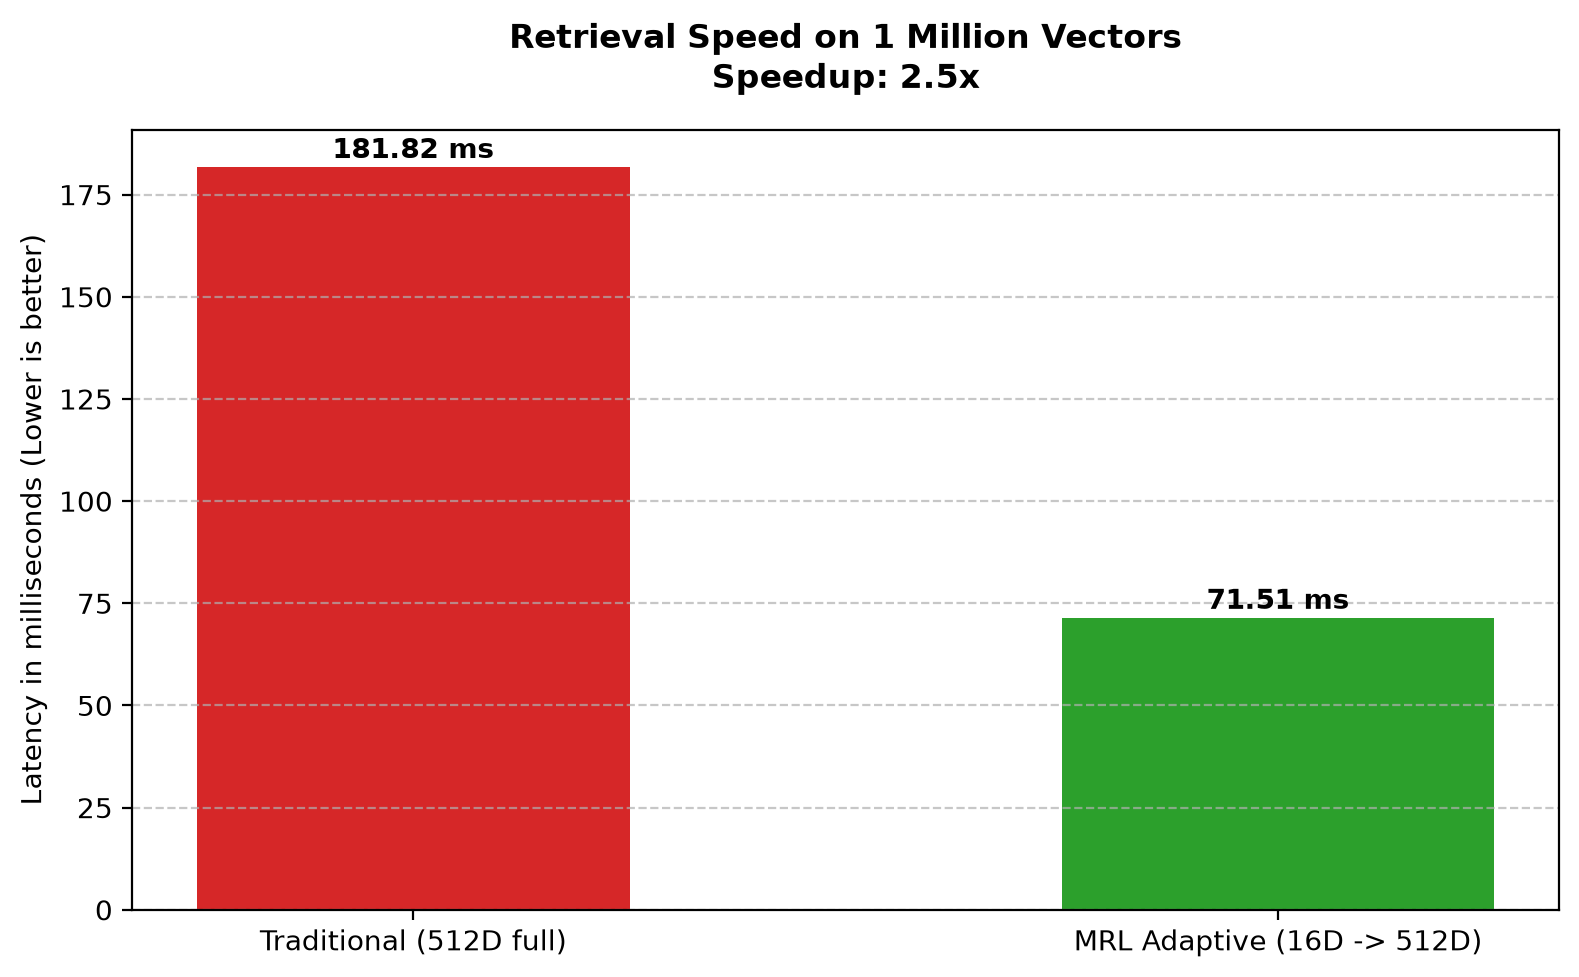

In [10]:
labels = ['Traditional (512D full)', 'MRL Adaptive (16D -> 512D)']
times = [trad_time, mrl_time]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, times, color=['#d62728', '#2ca02c'], width=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.2f} ms", ha='center', va='bottom', fontweight='bold')

plt.ylabel("Latency in milliseconds (Lower is better)")
plt.title(f"Retrieval Speed on 1 Million Vectors\nSpeedup: {trad_time / mrl_time:.1f}x", pad=15, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()